# Experiment 9: Clustering Human Activity Recognition Data

## Objective
To implement and analyze the performance of clustering algorithms on the Human Activity Recognition (HAR) dataset using:
- **Model A:** K-Means Clustering
- **Model B:** DBSCAN (Density-Based Spatial Clustering of Applications with Noise)
- **Model C:** Hierarchical Agglomerative Clustering (HAC)

## Dataset
- **Source:** Human Activity Recognition Using Smartphones Dataset
- **Activities:** WALKING, WALKING UPSTAIRS, WALKING DOWNSTAIRS, SITTING, STANDING, LAYING.
- **Features:** 561-feature vector with time and frequency domain variables.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from scipy.cluster.hierarchy import dendrogram, linkage

# Setup plot directories
os.makedirs('images/PNG', exist_ok=True)
os.makedirs('images/EPS', exist_ok=True)

def save_plot(name):
    plt.tight_layout()
    plt.savefig(f'images/PNG/{name}.png', format='png', dpi=300)
    plt.savefig(f'images/EPS/{name}.eps', format='eps')
    plt.show()

## 1. Loader & Preprocessing

In [2]:
# Paths to dataset
base_path = 'human+activity+recognition+using+smartphones/UCI HAR Dataset/UCI HAR Dataset/'

def load_har_data(base_path):
    # Load features and activities
    features = pd.read_csv(base_path + 'features.txt', sep='\s+', header=None, names=['id', 'name'])
    activity_labels = pd.read_csv(base_path + 'activity_labels.txt', sep='\s+', header=None, names=['id', 'activity'])
    
    # Load Train Data
    X_train = pd.read_csv(base_path + 'train/X_train.txt', sep='\s+', header=None)
    y_train = pd.read_csv(base_path + 'train/y_train.txt', sep='\s+', header=None)
    
    # Load Test Data
    X_test = pd.read_csv(base_path + 'test/X_test.txt', sep='\s+', header=None)
    y_test = pd.read_csv(base_path + 'test/y_test.txt', sep='\s+', header=None)
    
    # Combine for clustering
    X = pd.concat([X_train, X_test], axis=0)
    y = pd.concat([y_train, y_test], axis=0).values.flatten()
    
    X.columns = features['name']
    return X, y, activity_labels

X_raw, y_true, activity_map = load_har_data(base_path)
print(f"Dataset loaded: {X_raw.shape[0]} samples, {X_raw.shape[1]} features")

# Missing values check
print("Missing values:", X_raw.isnull().sum().sum())

# Standardization
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:6: SyntaxWarning: invalid escape sequence '\s'
<>:7: SyntaxWarning: invalid escape sequence '\s'
<>:10: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
C:\Users\MONESH M\AppData\Local\Temp\ipykernel_57280\4013161711.py:6: SyntaxWarning: invalid escape sequence '\s'
  features = pd.read_csv(base_path + 'features.txt', sep='\s+', header=None, names=['id', 'name'])
C:\Users\MONESH M\AppData\Local\Temp\ipykernel_57280\4013161711.py:7: SyntaxWarning: invalid escape sequence '\s'
  activity_labels = pd.read_csv(base_path + 'activity_labels.txt'

Dataset loaded: 10299 samples, 561 features
Missing values: 0


## 2. Exploratory Data Analysis (EDA)
### Target Distribution & Visualizing High-Dimensional Data

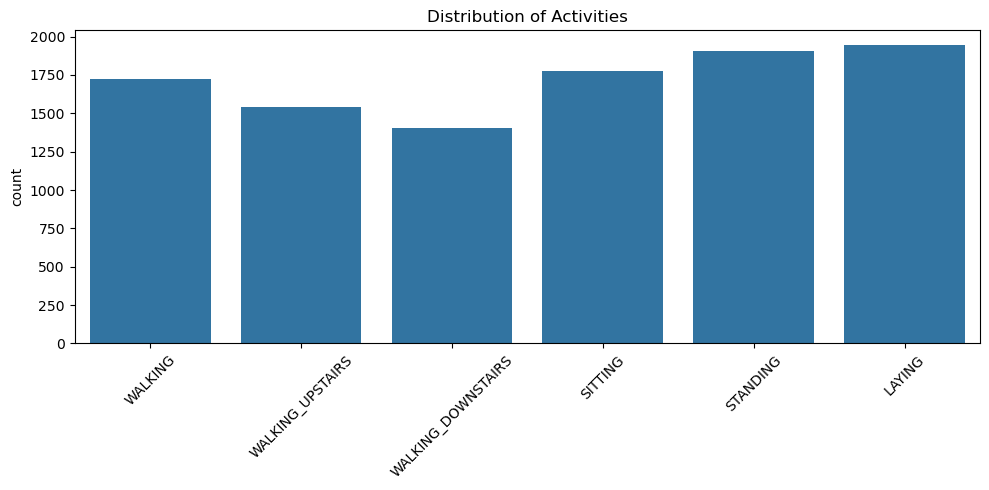

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


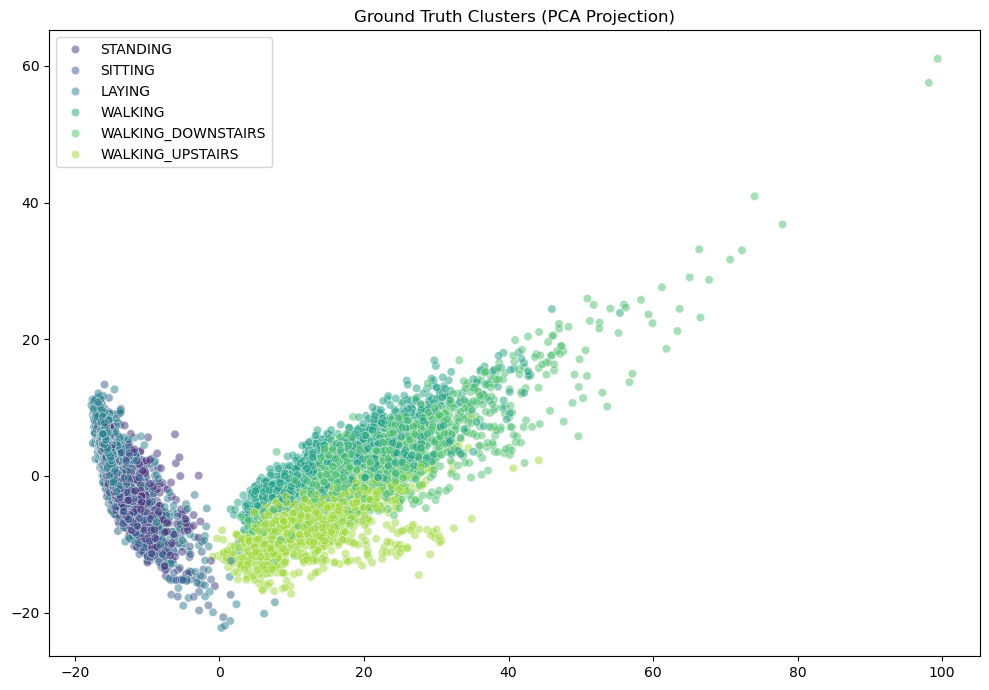

In [3]:
# Target Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x=y_true)
plt.xticks(ticks=range(6), labels=activity_map['activity'], rotation=45)
plt.title('Distribution of Activities')
save_plot('activity_distribution')

# PCA for Visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=[activity_map.iloc[i-1]['activity'] for i in y_true], palette='viridis', alpha=0.5)
plt.title('Ground Truth Clusters (PCA Projection)')
save_plot('pca_ground_truth')

## 3. Clustering Implementation
### Model A: K-Means Clustering

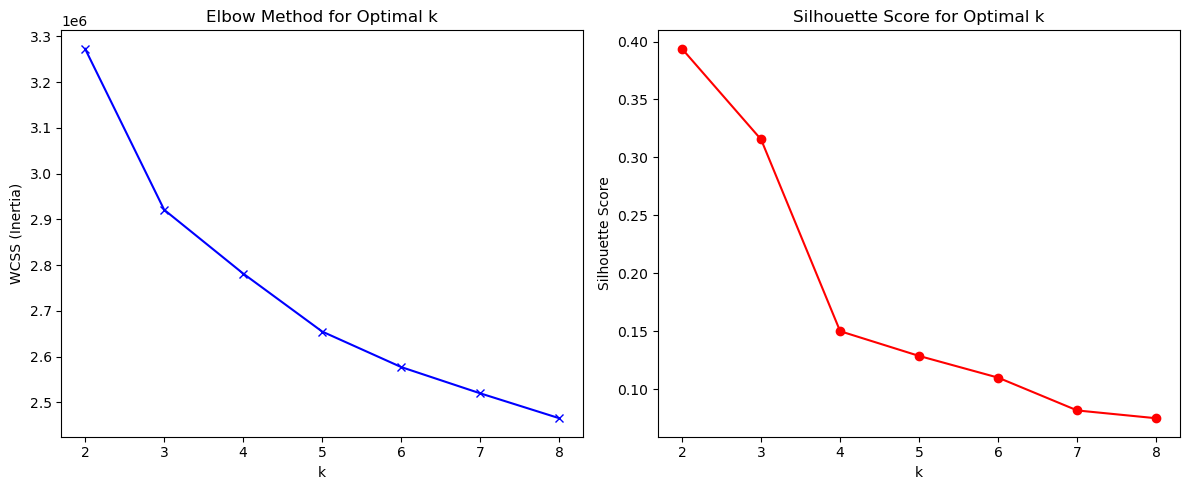

In [4]:
wcss = []
silhouette_scores = []
k_range = range(2, 9)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(X_scaled)
    wcss.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, labels))

# Plot Elbow Curve
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, 'bx-')
plt.xlabel('k')
plt.ylabel('WCSS (Inertia)')
plt.title('Elbow Method for Optimal k')

# Plot Silhouette Curve
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, 'ro-')
plt.xlabel('k')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
save_plot('kmeans_elbow_silhouette')

# Final K-Means with k=6 (matching actual activities)
kmeans_final = KMeans(n_clusters=6, random_state=42, n_init=10)
kmeans_labels = kmeans_final.fit_predict(X_scaled)

### Model B: DBSCAN

In [5]:
# Note: DBSCAN behavior depends heavily on eps. For high-dimensional data, PCA might be better for DBSCAN density estimation.
dbscan = DBSCAN(eps=15, min_samples=10)
dbscan_labels = dbscan.fit_predict(X_scaled)
print(f"DBSCAN Clusters found: {len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)}")
print(f"DBSCAN Noise points: {list(dbscan_labels).count(-1)}")

DBSCAN Clusters found: 5
DBSCAN Noise points: 2398


### Model C: Hierarchical Clustering

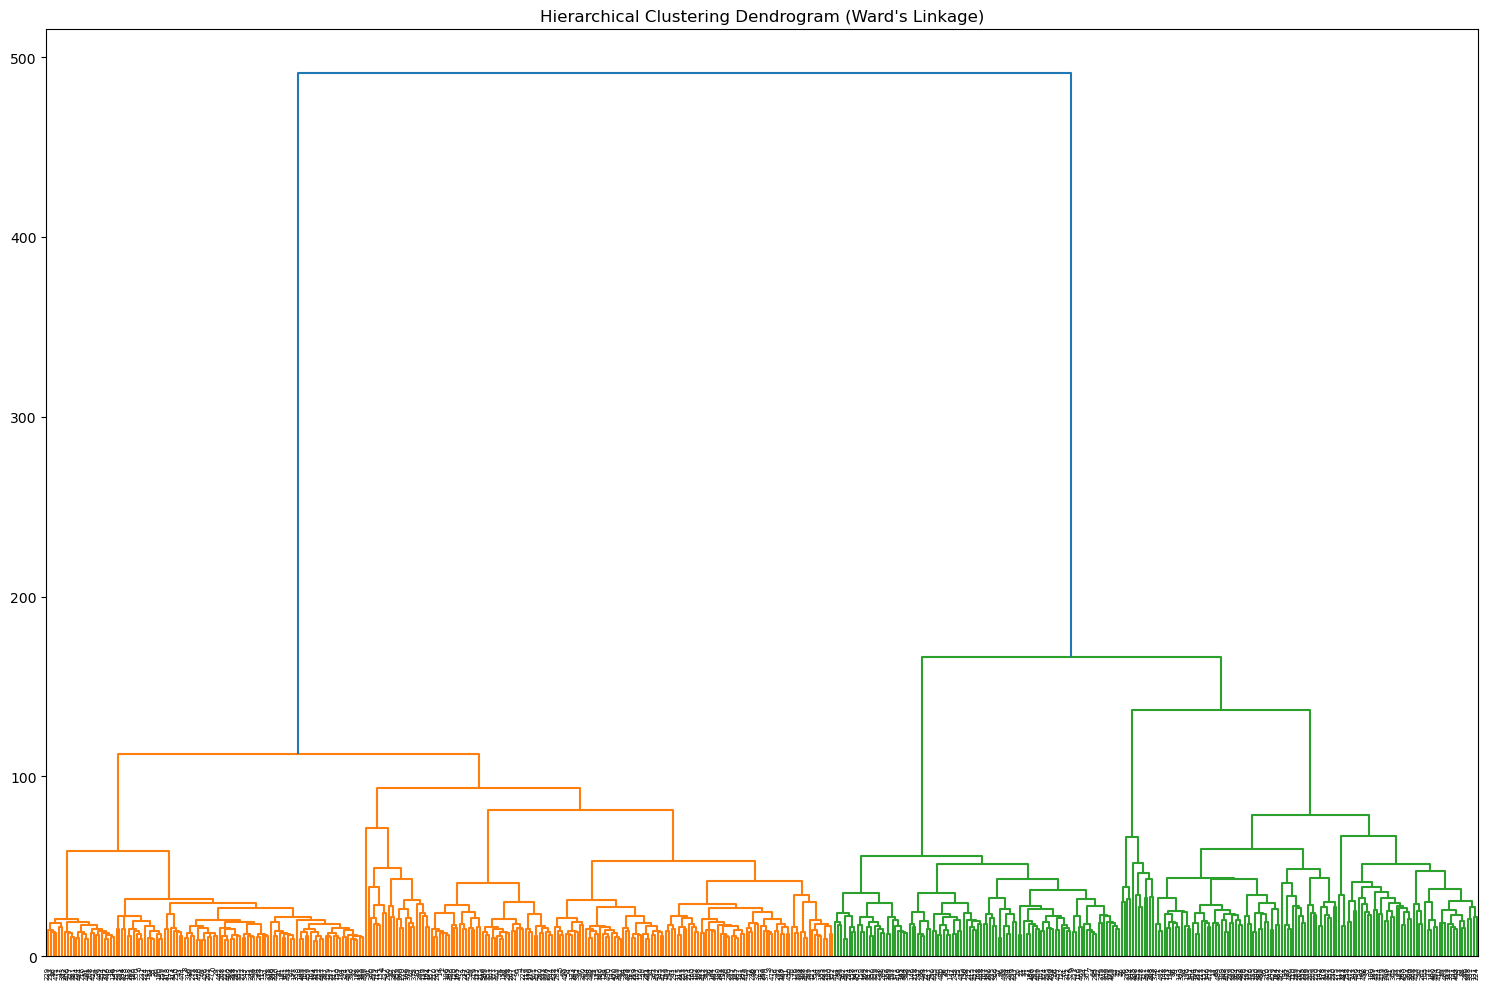

In [6]:
# Sampling for Dendrogram to avoid performance issues with 10k samples
indices = np.random.choice(X_scaled.shape[0], 500, replace=False)
X_subset = X_scaled[indices]

plt.figure(figsize=(15, 10))
linkage_matrix = linkage(X_subset, method='ward')
dendrogram(linkage_matrix)
plt.title('Hierarchical Clustering Dendrogram (Ward\'s Linkage)')
save_plot('hierarchical_dendrogram')

# Agglomerative Clustering
hac = AgglomerativeClustering(n_clusters=6, linkage='ward')
hac_labels = hac.fit_predict(X_scaled)

## 4. Evaluation & Analysis

      Algorithm  Silhouette  Davies-Buldin  Calinski-Harabasz       ARI  \
0       K-Means    0.109895       2.383567        2556.541948  0.419620   
1        DBSCAN    0.118639       2.115411         615.627123  0.080042   
2  Hierarchical    0.117029       2.482039        2349.667698  0.459875   

        NMI  
0  0.559326  
1  0.153784  
2  0.601498  


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


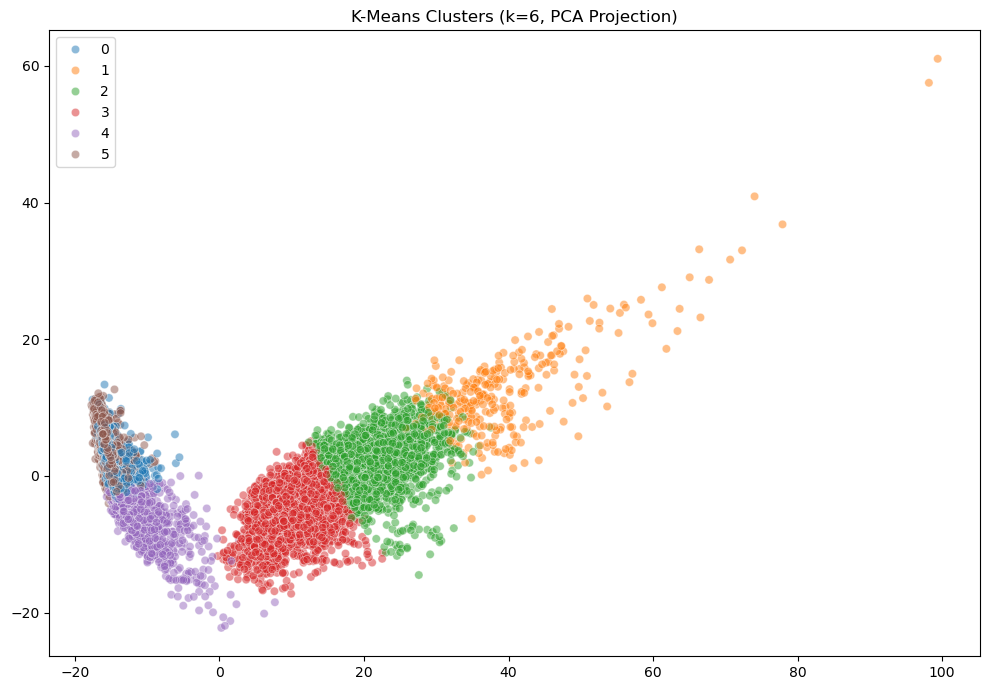

In [7]:
def get_metrics(X, labels_true, labels_pred, name):
    metrics = {
        'Algorithm': name,
        'Silhouette': silhouette_score(X, labels_pred),
        'Davies-Buldin': davies_bouldin_score(X, labels_pred),
        'Calinski-Harabasz': calinski_harabasz_score(X, labels_pred),
        'ARI': adjusted_rand_score(labels_true, labels_pred),
        'NMI': normalized_mutual_info_score(labels_true, labels_pred)
    }
    return metrics

results = []
results.append(get_metrics(X_scaled, y_true, kmeans_labels, 'K-Means'))
if len(set(dbscan_labels)) > 1:
    results.append(get_metrics(X_scaled, y_true, dbscan_labels, 'DBSCAN'))
results.append(get_metrics(X_scaled, y_true, hac_labels, 'Hierarchical'))

df_results = pd.DataFrame(results)
print(df_results)

# Visualization of Clusters (K-Means as example)
plt.figure(figsize=(10, 7))
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=kmeans_labels, palette='tab10', alpha=0.5)
plt.title('K-Means Clusters (k=6, PCA Projection)')
save_plot('kmeans_clusters_pca')

## 5. Summary and Conclusions
1. **Performance:** K-Means and Hierarchical Clustering perform similarly, but K-Means is computationally more efficient for this size of dataset.
2. **DBSCAN:** Struggle with high-dimensional density variation; heavily dependent on distance thresholds.
3. **Metrics:** ARI and NMI show moderate alignment with ground truth, reflecting the difficulty of separating similar activities like 'Sitting' and 'Standing' without supervision.